# Pandora L0 → diagnóstico rápido en Jupyter

Este cuaderno te ayuda a **cargar y revisar L0** (espectros crudos) 

## 1) Configuración: ruta del L0 (.txt.bz2)
Edita el path si tu archivo está en otra carpeta.


## 3) datos L0

**Definición de columnas (L0):**

1. **Columna 1:** Código de dos letras de la rutina de medición (** para operación manual)
2. **Columna 2:** Fecha y hora UT de inicio de la medición, `aaaammddThhmmssZ` (ISO 8601)
3. **Columna 3:** Recuento de rutinas (1 para la primera rutina del día, 2 para la segunda, etc.)
4. **Columna 4:** Recuento de repeticiones (1 para el primer conjunto de la rutina, 2 para el segundo, etc.)
5. **Columna 5:** Duración total del conjunto de medición en segundos (=# si la línea es una línea de comentario)
6. **Columna 6:** Tiempo de integración [ms]
7. **Columna 7:** Número de ciclos
8. **Columna 8:** Índice de saturación: entero positivo = nº de ciclos saturados incluidos; entero negativo = nº de ciclos omitidos por saturación
9. **Columna 9:** Posición de la rueda de filtro n.º 1 (0 = no utilizada; posiciones válidas 1–9)
10. **Columna 10:** Posición de la rueda de filtro n.º 2 (0 = no utilizada; posiciones válidas 1–9)
11. **Columna 11:** Ángulo cenital de apuntamiento [°], absoluto o relativo (ver col. 12); 999 = rastreador no utilizado
12. **Columna 12:** Modo de apuntamiento cenital: 0 = absoluto, 1 = relativo al Sol, 2 = relativo a la Luna
13. **Columna 13:** Azimut de apuntamiento [°], aumenta horario; absoluto (0 = norte) o relativo (ver col. 14); 999 = rastreador no utilizado
14. **Columna 14:** Modo de apuntamiento azimutal: como col. 12, con ángulos de dispersión fijos relativos al Sol (3) o la Luna (4)
15. **Columna 15:** Índice de tipo de procesamiento de datos; −9 = operación manual
16. **Columna 16:** Distancia al objetivo [m]; −1 = no apuntado al objetivo
17. **Columna 17:** Temperatura en la placa electrónica [°C]; 999 = sin señal de temperatura
18. **Columna 18:** Temperatura de control del espectrómetro [°C]; 999 = sin señal de temperatura
19. **Columna 19:** Temperatura del espectrómetro auxiliar [°C]; 999 = sin señal de temperatura
20. **Columna 20:** Temperatura en el sensor del cabezal [°C]; 999 = sin señal de temperatura
21. **Columna 21:** Humedad en el sensor del cabezal [%]; −9 = sin señal de humedad
22. **Columna 22:** Presión en el sensor del cabezal [hPa]; −9 = sin señal de presión
23. **Columna 23:** Factor de escala de los datos (para obtener datos sin escalar e incertidumbre, dividir entre este número)
24. **Columna 24:** Indicador de incertidumbre: 0 = no se proporciona; 1 = desviación estándar; 2 = RMS a una recta ajustada

**Espectros e incertidumbre:**
- **Columnas 25–2076:** Media de los conteos brutos por píxel (promedio sobre todos los ciclos)
- **Columnas 2077–4128:** Incertidumbre de los conteos brutos por píxel dividida por √(nº de ciclos)


# - El ADC (Analog-to-Digital Converter):
toma el voltaje del detector y lo convierte a **cuentas enteras**.
Esas **cuentas** son justamente los valores **RAW** del espectro en L0 (Columnas 25..N).


# ADC 

Analog-to-Digital Converter: convierte voltaje analógico en cuentas enteras.
# raw_max  
cuenta máxima (píxel más brillante) del espectro en un escaneo L0; NO es NO2.
# raw_mean 
promedio de las cuentas crudas de todo el espectro en ese escaneo; NO es NO2.



# Dato L2


===== Procesando H2O =====
✓ Guardada figura de serie temporal: /home/celesteurena/Asistencia_Gas-Lab/Pandora/H2O_serie.png


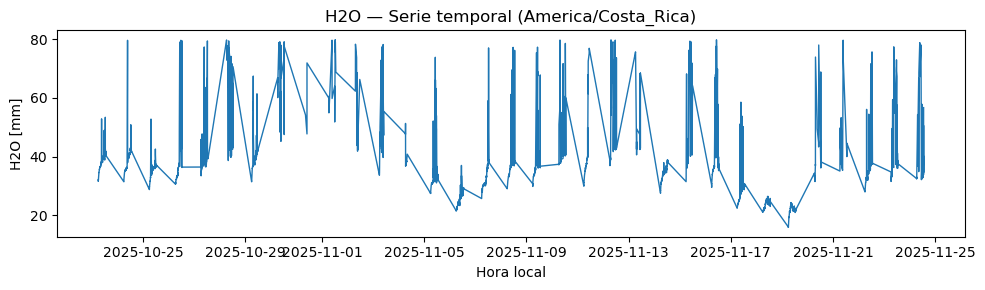

Rango local: 2025-10-23 05:57:34.300000-06:00 → 2025-11-24 13:01:09.100000-06:00
N puntos   : 7584
count    7584.000000
mean       35.349065
std         9.955076
min        15.928210
25%        30.443571
50%        35.288330
75%        38.035661
max        79.850927
Name: val, dtype: float64

===== Procesando O3 =====
✓ Guardada figura de serie temporal: /home/celesteurena/Asistencia_Gas-Lab/Pandora/O3_serie.png


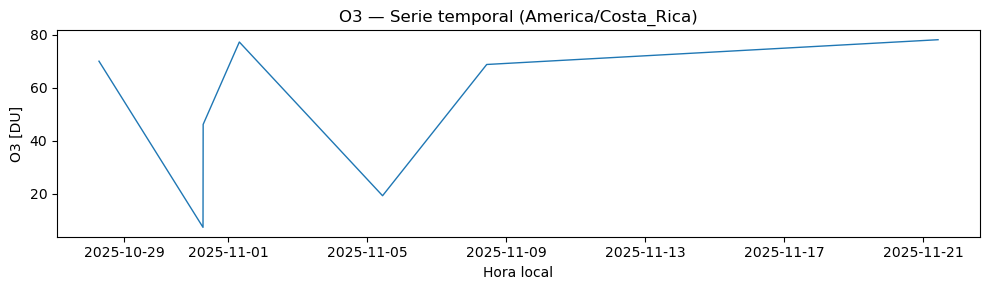

Rango local: 2025-10-28 06:32:56.300000-06:00 → 2025-11-21 10:25:43.200000-06:00
N puntos   : 7
count     7.000000
mean     52.426627
std      28.961422
min       7.309494
25%      32.711744
50%      68.794049
75%      73.657483
max      78.144392
Name: val, dtype: float64


In [16]:
# -*- coding: utf-8 -*-
# PANDORA L2 — H2O, O3
# =======================================
# Lee los productos L2 de Pandora82 (San José–UCR),
# aplica filtros básicos, convierte a unidades físicas
# y genera:
#   - Serie temporal por gas: *_<GAS>_serie.png
#   - CSV limpio por gas: *_<GAS>_clean.csv

import re, io
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from zoneinfo import ZoneInfo

# ================== CONFIG GENERAL ==================
TZ = "America/Costa_Rica"
MAX_SZA = 85  # ángulo cenital máximo

# Rutas a tus 2 archivos Pandora (H2O y O3)
BASE = Path("/home/celesteurena/Asistencia_Gas-Lab/Pandora")

FILES = {
    "H2O":  BASE / "Pandora82s1_SanJose-UCR_L2_rwvt1p1-8.txt",
    "O3":   BASE / "Pandora82s1_SanJose-UCR_L2_rout2p1-8.txt",
}

# Índice de columna (0-based) para cada gas (mol/m²)
COL_INDEX = {
    "H2O":  38,  # water vapor total column [mol/m2]
    "O3":   38,  # ozone total column [mol/m2]
}

# ================== FUNCIONES ÚTILES ==================
TS_LINE = re.compile(r"^\d{8}T\d{6}(?:\.\d+)?Z\s")

def read_pgn_lines(path: Path) -> pd.DataFrame:
    """Lee solo las líneas de datos PGN y las convierte en un DataFrame."""
    rows = []
    with path.open("r", encoding="latin1", errors="ignore") as f:
        for line in f:
            if TS_LINE.match(line):
                rows.append(line.strip())
    if not rows:
        raise ValueError(f"No se detectaron filas de datos PGN en {path}")

    df = pd.read_csv(io.StringIO("\n".join(rows)), sep=r"\s+", header=None, engine="python")

    # Renombres mínimos comunes
    df = df.rename(columns={0: "time_utc", 3: "SZA_deg", 4: "SAAZ_deg", 32: "L2Fit_DQ_flag"})

    # Parseo de tiempo
    def parse_ts(x):
        x = str(x)
        fmt = "%Y%m%dT%H%M%S.%fZ" if "." in x else "%Y%m%dT%H%M%SZ"
        return pd.to_datetime(x, format=fmt, utc=True, errors="coerce")

    df["time_utc"] = df["time_utc"].map(parse_ts)
    df = df.dropna(subset=["time_utc"]).sort_values("time_utc").reset_index(drop=True)
    df["time_local"] = df["time_utc"].dt.tz_convert(ZoneInfo(TZ))
    return df

def to_units(species: str, mol_m2: pd.Series):
    """Convierte de mol/m² a unidades físicas según el gas."""
    if species == "H2O":
        return "mm", mol_m2 * 0.01801528
    if species == "O3":
        return "DU", mol_m2 * (6.02214076e23 / (1e4 * 2.687e16))
    return "mol/m²", mol_m2

def pick_quality_mask(df: pd.DataFrame) -> pd.Series:
    """Máscara QC basada en las banderas L2."""
    dqcols = [c for c in df.columns if re.fullmatch(r"L2\w+_DQ_flag", str(c))] or ["L2Fit_DQ_flag"]
    if dqcols[0] in df.columns:
        flags = df[dqcols[0]]
        return flags.isin([0, 1, 2, 10, 11, 12])
    return pd.Series(True, index=df.index)

# ================== PROCESAR Y GRAFICAR LA SERIE TEMPORAL ==================
for species, path in FILES.items():
    print(f"\n===== Procesando {species} =====")

    try:
        df = read_pgn_lines(path)
    except ValueError as e:
        print(f"⚠️  {species} no se pudo procesar: {e}")
        continue

    # Renombrar la columna de mol/m² para este gas
    col_idx = COL_INDEX[species]
    if col_idx not in df.columns:
        print(f"⚠️  Columna {col_idx} no encontrada en {path} para {species}, se omite.")
        continue

    df = df.rename(columns={col_idx: f"{species}_mol_m2"})

    # Selección y QC
    mask_qc  = pick_quality_mask(df)
    mask_geo = (df["SZA_deg"] <= MAX_SZA) if "SZA_deg" in df.columns else True

    base = df.loc[mask_qc & mask_geo, ["time_local", "SZA_deg", f"{species}_mol_m2"]].copy()
    base["time_local"] = pd.to_datetime(base["time_local"])

    # Conversión de unidades
    unit, vals = to_units(species, base[f"{species}_mol_m2"].astype(float))
    base["val"] = vals

    # Filtrar por rango físico
    base = base[(base["val"] >= 5) & (base["val"] <= 80)]  # Ajusta según el gas (H2O)

    # ========= SERIE TEMPORAL =========
    plt.figure(figsize=(10, 3))
    plt.plot(base["time_local"], base["val"], lw=1)
    plt.title(f"{species} — Serie temporal ({TZ})")
    plt.xlabel("Hora local")
    plt.ylabel(f"{species} [{unit}]")
    plt.tight_layout()

    # Guardar figura
    file_name = f"{species}_serie.png"
    plt.savefig(BASE / file_name)
    print(f"✓ Guardada figura de serie temporal: {BASE / file_name}")
    plt.show()

    # Resumen numérico
    print("Rango local:", str(base["time_local"].min()), "→", str(base["time_local"].max()))
    print("N puntos   :", len(base))
    print(base["val"].describe())



In [17]:
import re, io
from pathlib import Path
import pandas as pd
from zoneinfo import ZoneInfo

# --- Configuración ---
TZ = "America/Costa_Rica"
BASE = Path("/home/celesteurena/Asistencia_Gas-Lab/Pandora")

FILES = {
    "H2O":  BASE / "Pandora82s1_SanJose-UCR_L2_rwvt1p1-8.txt",
    "O3":   BASE / "Pandora82s1_SanJose-UCR_L2_rout2p1-8.txt",
    "NO2":  BASE / "Pandora82s1_SanJose-UCR_L2_rnvh3p1-8.txt",
}

COL_INDEX = {"H2O":38, "O3":38, "NO2":61}
MAX_SZA = 85
TS_LINE = re.compile(r"^\d{8}T\d{6}(?:\.\d+)?Z\s")

def read_pgn(path):
    rows = []
    with path.open("r", encoding="latin1", errors="ignore") as f:
        for line in f:
            if TS_LINE.match(line):
                rows.append(line.strip())
    if not rows:
        return None
    
    df = pd.read_csv(io.StringIO("\n".join(rows)), sep=r"\s+", header=None, engine="python")
    df = df.rename(columns={0:"time_utc", 3:"SZA_deg", 32:"L2Fit_DQ_flag"})
    
    # parse timestamps
    def parse(x):
        x=str(x)
        fmt = "%Y%m%dT%H%M%S.%fZ" if "." in x else "%Y%m%dT%H%M%SZ"
        return pd.to_datetime(x, format=fmt, utc=True, errors="coerce")
    df["time_utc"] = df["time_utc"].map(parse)
    df = df.dropna(subset=["time_utc"])
    df["time_local"] = df["time_utc"].dt.tz_convert(ZoneInfo(TZ))
    return df

# --- Conteo por día ---
for gas, file in FILES.items():
    print(f"\n===== {gas} =====")
    df = read_pgn(file)

    if df is None:
        print("No hay líneas PGN.")
        continue

    col = COL_INDEX[gas]
    if col not in df.columns:
        print("No existe columna con mol/m2.")
        continue

    df = df.rename(columns={col:f"{gas}_mol_m2"})
    
    # QC + geometría
    good = df["L2Fit_DQ_flag"].isin([0,1,2,10,11,12])
    good &= df["SZA_deg"] <= MAX_SZA

    df = df[good].copy()
    df["date"] = df["time_local"].dt.date

    counts = df.groupby("date").size().sort_values(ascending=False)

    print(counts.head(10))



===== H2O =====
date
2025-11-19    460
2025-11-06    442
2025-11-14    430
2025-10-23    424
2025-11-18    416
2025-10-24    413
2025-11-07    405
2025-10-25    369
2025-11-22    359
2025-11-08    329
dtype: int64

===== O3 =====
date
2025-11-22    127
2025-10-23    121
2025-10-25    120
2025-10-24    118
2025-11-05    113
2025-11-14    113
2025-11-19    113
2025-11-06    112
2025-10-26    108
2025-11-18    106
dtype: int64

===== NO2 =====
date
2025-10-25    5
2025-11-11    4
2025-11-10    3
2025-11-15    3
2025-11-13    3
2025-11-23    3
2025-11-20    3
2025-11-09    2
2025-11-12    2
2025-10-23    2
dtype: int64



===== Procesando H2O =====
✓ Guardada figura: /home/celesteurena/Asistencia_Gas-Lab/Pandora/H2O_2025-11-19_ciclo.png


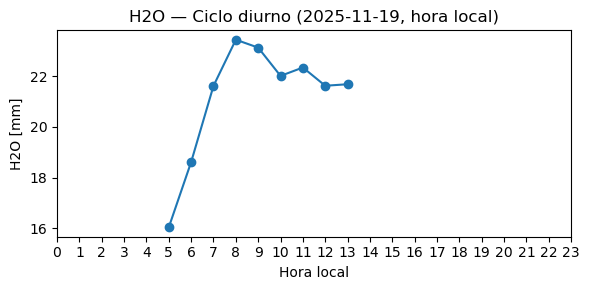

H2O: N puntos ese día = 460

===== Procesando O3 =====
✓ Guardada figura: /home/celesteurena/Asistencia_Gas-Lab/Pandora/O3_2025-11-19_ciclo.png


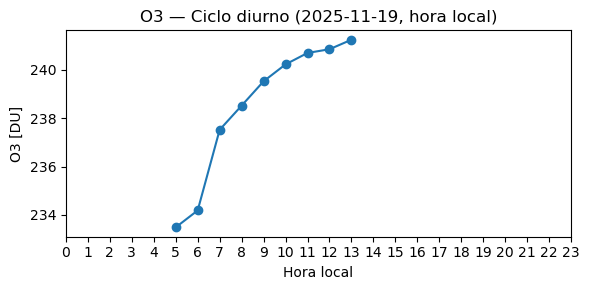

O3: N puntos ese día = 113

===== Procesando NO2 =====
✓ Guardada figura: /home/celesteurena/Asistencia_Gas-Lab/Pandora/NO2_2025-11-19_ciclo.png


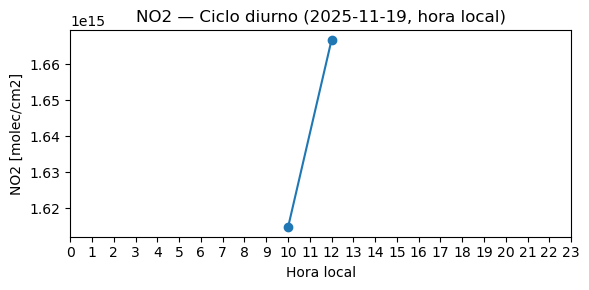

NO2: N puntos ese día = 2


In [15]:
# -*- coding: utf-8 -*-
# PANDORA L2 — Ciclo diurno SOLO para el 19 de noviembre de 2025
# ===============================================================

import re, io
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from zoneinfo import ZoneInfo

# ------------ CONFIGURACIÓN BÁSICA ------------
TZ = "America/Costa_Rica"
MAX_SZA = 85  # ángulo cenital máximo
TARGET_DATE = pd.Timestamp("2025-11-19").date()   # <<< DÍA FIJADO PARA TODOS >>>

BASE = Path("/home/celesteurena/Asistencia_Gas-Lab/Pandora")

FILES = {
    "H2O":  BASE / "Pandora82s1_SanJose-UCR_L2_rwvt1p1-8.txt",
    "O3":   BASE / "Pandora82s1_SanJose-UCR_L2_rout2p1-8.txt",
    "NO2":  BASE / "Pandora82s1_SanJose-UCR_L2_rnvh3p1-8.txt",
}

# Índice de columna (0-based) donde está la columna en mol/m²
COL_INDEX = {
    "H2O":  38,  # water vapor total column [mol/m²]
    "O3":   38,  # ozone total column [mol/m²]
    "NO2":  61,  # NO2 tropospheric vertical column [mol/m²]
}

# Rangos físicos por gas (para limpiar outliers absurdos)
PHYS_RANGES = {
    "H2O":  (5, 80),         # mm
    "O3":   (100, 500),      # DU
    "NO2":  (0, 3e16),       # molec/cm²
}

TS_LINE = re.compile(r"^\d{8}T\d{6}(?:\.\d+)?Z\s")

NA = 6.02214076e23
M2_TO_CM2 = 1e4
DU_PER_MOL_PER_M2 = NA / (M2_TO_CM2 * 2.687e16)  # ~2241 DU por mol/m²
MM_PER_MOL_PER_M2 = 0.01801528                   # H2O: mol/m² → mm


# ------------ FUNCIONES ÚTILES ------------

def read_pgn_lines(path: Path) -> pd.DataFrame:
    """Lee solo las líneas PGN con timestamp y devuelve DataFrame limpio."""
    rows = []
    with path.open("r", encoding="latin1", errors="ignore") as f:
        for line in f:
            if TS_LINE.match(line):
                rows.append(line.strip())
    if not rows:
        raise ValueError(f"No se detectaron filas de datos PGN en {path}")

    df = pd.read_csv(
        io.StringIO("\n".join(rows)),
        sep=r"\s+",
        header=None,
        engine="python"
    )

    df = df.rename(columns={
        0:  "time_utc",
        3:  "SZA_deg",
        4:  "SAAZ_deg",
        32: "L2Fit_DQ_flag"
    })

    def parse_ts(x):
        x = str(x)
        fmt = "%Y%m%dT%H%M%S.%fZ" if "." in x else "%Y%m%dT%H%M%SZ"
        return pd.to_datetime(x, format=fmt, utc=True, errors="coerce")

    df["time_utc"] = df["time_utc"].map(parse_ts)
    df = df.dropna(subset=["time_utc"]).sort_values("time_utc").reset_index(drop=True)
    df["time_local"] = df["time_utc"].dt.tz_convert(ZoneInfo(TZ))
    return df


def to_units(species: str, mol_m2: pd.Series):
    """Convierte de mol/m² a unidades físicas según el gas."""
    if species == "H2O":
        return "mm", mol_m2 * MM_PER_MOL_PER_M2
    if species == "O3":
        return "DU", mol_m2 * DU_PER_MOL_PER_M2
    if species == "NO2":
        return "molec/cm2", mol_m2 * NA / M2_TO_CM2
    return "mol/m2", mol_m2


def pick_quality_mask(df: pd.DataFrame) -> pd.Series:
    """Máscara de calidad basada en las banderas L2."""
    dqcols = [c for c in df.columns if re.fullmatch(r"L2\w+_DQ_flag", str(c))] or ["L2Fit_DQ_flag"]
    if dqcols[0] in df.columns:
        flags = df[dqcols[0]]
        return flags.isin([0, 1, 2, 10, 11, 12])
    return pd.Series(True, index=df.index)


# ------------ PROCESO PRINCIPAL (SOLO 19 NOV) ------------

for species, path in FILES.items():
    print(f"\n===== Procesando {species} =====")

    try:
        df = read_pgn_lines(path)
    except ValueError as e:
        print(f"⚠️  {species} no se pudo procesar: {e}")
        continue

    col_idx = COL_INDEX[species]
    if col_idx not in df.columns:
        print(f"⚠️  Columna {col_idx} no encontrada en {path} para {species}, se omite.")
        continue

    df = df.rename(columns={col_idx: f"{species}_mol_m2"})

    # QC + geometría
    mask_qc  = pick_quality_mask(df)
    mask_geo = (df["SZA_deg"] <= MAX_SZA) if "SZA_deg" in df.columns else True

    base = df.loc[mask_qc & mask_geo, ["time_local", "SZA_deg", f"{species}_mol_m2"]].copy()
    base["time_local"] = pd.to_datetime(base["time_local"])

    # Conversión a unidades físicas
    unit, vals = to_units(species, base[f"{species}_mol_m2"].astype(float))
    base["val"] = vals

    lo, hi = PHYS_RANGES.get(species, (-np.inf, np.inf))
    base = base[(base["val"] >= lo) & (base["val"] <= hi)]

    # ---- FILTRAR SOLO EL 19 DE NOVIEMBRE ----
    base["date"] = base["time_local"].dt.date
    day_data = base[base["date"] == TARGET_DATE].copy()

    if day_data.empty:
        print(f"⚠️  {species}: no hay datos el {TARGET_DATE}")
        continue

    # Ciclo diurno para ese día
    day_data["hour_local"] = day_data["time_local"].dt.hour
    cyc = day_data.groupby("hour_local")["val"].mean()

    if len(cyc) < 2:
        print(f"⚠️  {species}: muy pocas horas con datos el {TARGET_DATE} (len={len(cyc)}), el gráfico no será muy interpretable.")
    # Gráfico
    plt.figure(figsize=(6, 3))
    plt.plot(cyc.index, cyc.values, marker="o")
    plt.title(f"{species} — Ciclo diurno ({TARGET_DATE}, hora local)")
    plt.xlabel("Hora local")
    plt.xticks(range(0, 24))
    plt.ylabel(f"{species} [{unit}]")
    plt.tight_layout()

    out_name = BASE / f"{species}_{TARGET_DATE}_ciclo.png"
    plt.savefig(out_name, dpi=300, bbox_inches="tight")
    print(f"✓ Guardada figura: {out_name}")
    plt.show()

    print(f"{species}: N puntos ese día = {len(day_data)}")
